In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'x'}

In [3]:
axis = OPTIONS.get('axis')
target_axis = ['roll', 'wx', 'az'] if axis == 'z' else ['pitch', 'wz', 'ax']
print(target_axis)

['pitch', 'wz', 'ax']


# DADOS

In [4]:
df = pd.read_csv('Format/files/output.csv')
df

,time,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,target_ax,target_yaw,static,ref_ay,ref_sample_time,ref_q1,ref_roll,ref_wz,ref_la_pos_mon_d,ref_wy,ref_q3,ref_pitch,ref_q2,ref_wx,ref_az,ref_ax,ref_q0,ref_yaw
0,0.0,9.816496,-0.971,-3.01151,56.9,0.00050,2.223,-0.684,0.54692,-0.072785,0.583564,11.628,False,9.770,605000000.0,-0.20360,-88.92305,3.089388,-1.404,-0.055961,0.6888,1.738354,-0.6702,0.042531,-0.1864,0.1592,0.186700,147.994998
1,0.1,9.770532,-0.901,-3.95340,57.0,0.45201,2.604,-0.468,0.72402,-0.107422,0.585722,11.625,False,9.777,705000000.0,-0.20560,-88.92305,3.720788,-1.404,-0.097346,0.6894,2.093015,-0.6696,0.043699,-0.1864,0.1522,0.184500,147.994998
2,0.2,9.784359,-0.824,-4.00435,56.9,-0.47514,3.016,-0.252,0.61244,-0.095164,0.561323,11.625,False,9.785,805000000.0,-0.20790,-88.92305,4.145350,-1.404,-0.161345,0.6901,2.496377,-0.6689,0.009305,-0.1857,0.1448,0.182000,147.994998
3,0.3,9.767002,-0.740,-4.19792,57.0,0.11488,3.447,0.036,0.63662,-0.081886,0.545456,11.633,False,9.791,905000000.0,-0.21030,-88.92305,4.332707,-1.404,-0.140375,0.6908,2.924950,-0.6681,0.008417,-0.1853,0.1363,0.179300,148.052294
4,0.4,9.806758,-0.656,-4.20634,56.9,-0.07570,3.871,0.432,0.71959,-0.108422,0.592724,11.639,False,9.795,5000000.0,-0.21280,-88.92305,4.283432,-1.404,-0.107773,0.6915,3.355814,-0.6673,-0.011471,-0.1852,0.1268,0.176600,148.052294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.774190,-0.638,-0.16637,57.4,-0.17294,3.337,0.468,-0.09776,-0.144550,0.576298,13.335,True,9.786,105000000.0,-0.03197,-88.92305,0.020506,2.007,-0.158423,0.7136,1.953786,-0.6998,0.002401,-0.1856,0.1385,0.008241,176.757480
1297,129.6,9.744397,-0.634,-0.58104,57.4,0.22483,3.339,0.468,-0.06197,-0.093879,0.572355,13.338,True,9.782,205000000.0,-0.03188,-88.92305,0.015539,2.005,-0.162777,0.7136,1.954932,-0.6998,-0.013694,-0.1846,0.1384,0.008133,176.757480
1298,129.7,9.749781,-0.635,0.03523,57.3,0.03419,3.341,0.468,0.12510,-0.134322,0.562608,13.338,True,9.784,305000000.0,-0.03179,-88.92305,0.009368,2.004,-0.158079,0.7136,1.955505,-0.6998,-0.002935,-0.1850,0.1378,0.008034,176.814776
1299,129.8,9.735395,-0.634,0.23015,57.4,-0.15196,3.341,0.468,0.07650,-0.094516,0.592214,13.339,True,9.784,405000000.0,-0.03170,-88.92305,0.009706,2.002,-0.172174,0.7136,1.956651,-0.6998,0.004946,-0.1851,0.1378,0.007925,176.814776


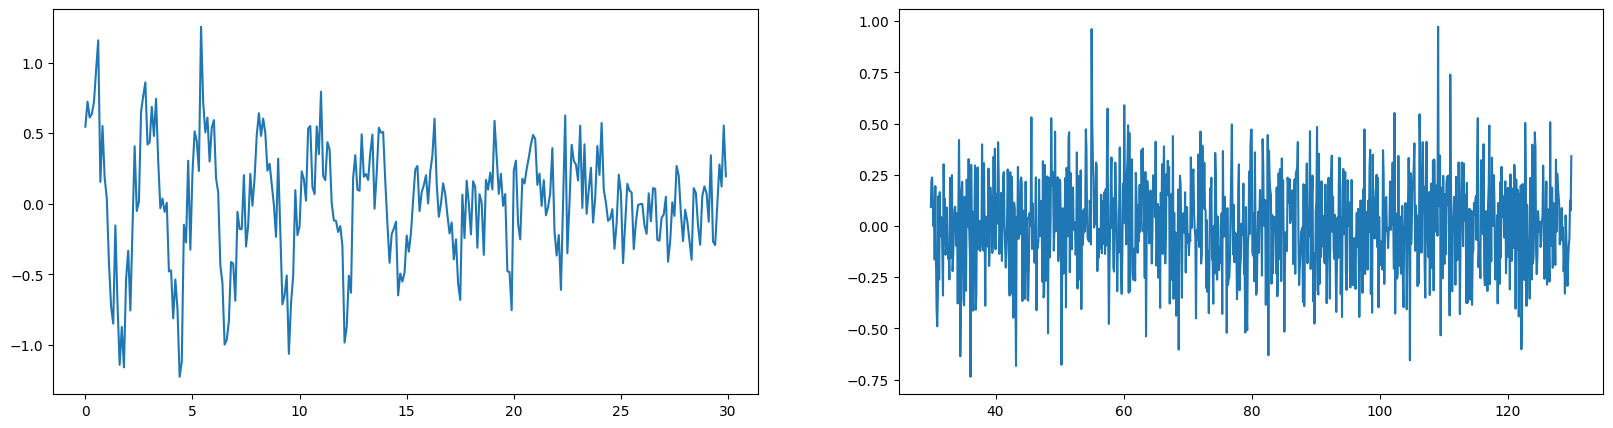

In [5]:
df_static  = df.loc[df.static]
df_dynamic = df.loc[~df.static]
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plt.plot(df_dynamic.time, df_dynamic.target_wx)
plt.subplot(1, 2, 2); plt.plot(df_static.time, df_static.target_wx)

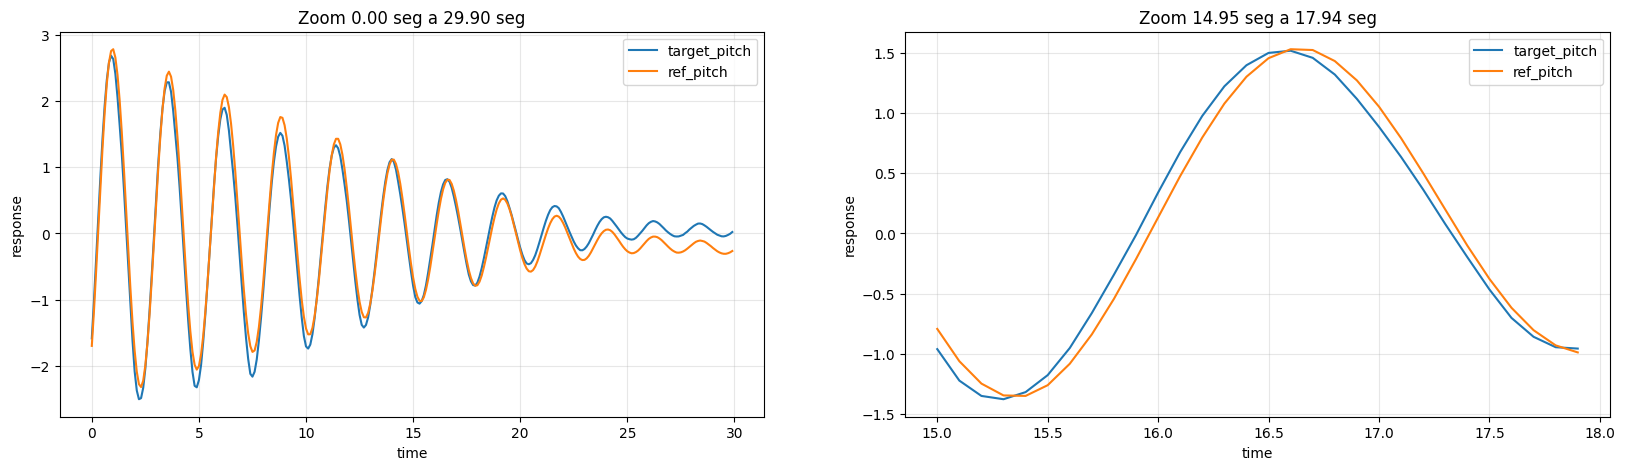

In [6]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target['target_' + varname] if not norm else normalize(target['target_' + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label='target_' + varname)
    plt.plot(target.time, values2, label='ref_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plotViews(df_dynamic, 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2); plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))

# DEFASAGEM

In [7]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])
        
        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if abs(lag) < 2:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


phaser = Phaser('target_pitch', 'ref_pitch')
lag    = phaser.get(df_dynamic)

df_dynamic = phaser.set(df_dynamic, lag)
df_static  = phaser.set(df_static, lag)
print('System LAG:', lag, 'samples')

System LAG: 0 samples


# MODELO DE CALIBRAÇÃO

In [8]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [9]:
class LinearFit:
    def __init__(self, df, variables, time_col='time', fuse=False):
        self.time = np.array(df[time_col])
        self.variables = variables
        self.fuse = fuse
        
        self.X = np.column_stack([df[f'target_{var}'] for var in variables])
        self.Y = np.column_stack([df[f'ref_{var}']    for var in variables])
        
        self.M = np.eye(3)
        self.B = np.zeros(3)

        self.Y_model = np.zeros_like(self.Y)
        self.errors  = np.zeros_like(self.Y)
        self.metrics = {}

    def update(self):
        N = self.X.shape[0]
        
        if not self.fuse: # y = ax + b
            self.M = np.zeros((len(self.variables), len(self.variables)))
            self.B = np.zeros(len(self.variables))
            
            for i in range(len(self.variables)):
                x_single = self.X[:, i].reshape(-1, 1)
                X_aug    = np.hstack((x_single, np.ones((N, 1))))
                w, _, _, _ = np.linalg.lstsq(X_aug, self.Y[:, i], rcond=None)
                
                self.M[i, i] = w[0]  # Scale
                self.B[i]    = w[1]  # Bias
                self.Y_model[:, i] = X_aug @ w
                
        else: # Fusão ativada
            X_aug = np.hstack((self.X, np.ones((N, 1))))
            W, _, _, _ = np.linalg.lstsq(X_aug, self.Y, rcond=None)
            
            self.M = W[:3, :].T
            self.B = W[3, :]
            self.Y_model = X_aug @ W
            
        self.errors = self.Y - self.Y_model
        
        for i, axis in enumerate(self.variables):
            error  = self.errors[:, i]
            y_data = self.Y[:, i]
            
            rmse = np.sqrt(np.mean(error**2))
            mae  = np.mean(np.abs(error))
            max_error = np.max(np.abs(error))
            std_noise = error.std()
            
            ss_res = np.sum(error**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)
            
            self.metrics[axis] = {
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
                'max_error': max_error,
                'std_noise': std_noise,
                'bias': self.B[i],
                'scale_factor': self.M[i, i]
            }

    def display(self):
        matrix_df = pd.DataFrame(self.M, columns=self.variables, index=[f'{ax}_model' for ax in self.variables])
        matrix_df['bias'] = self.B
        display(matrix_df.style.format("{:.6f}"))

    def plot(self, axis_id, view_limits=None):
        axis_name = self.variables[axis_id]
        t_max     = self.time[-1]
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        
        t_plot = self.time[mask]
        y_plot = self.Y[mask, axis_id]
        mod_plot = self.Y_model[mask, axis_id]
        err_plot = self.errors[mask, axis_id]
        mae = self.metrics[axis_name]["mae"]

        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='#6A3CBC', label='Reference', linewidth=2)
        plt.plot(t_plot, mod_plot, color='#E91E63', label='Model (Calibration)', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'{axis_name}')
        plt.legend()
        plt.title(f'{axis_name.capitalize()} - R2 Score {self.metrics[axis_name]["r2"]:.3f}')
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='#6A3CBC')
        plt.xlabel('Time (s)')
        plt.ylabel('Error')
        plt.title(f'Temporal Error - Mean: {mae:.3f}')
        plt.grid(alpha=0.3); plt.ylim(-mae*20, mae*20)
        plt.show()

    def predict(self, axis):
        return self.Y_model[:, axis]

groups = {
    'Euler Angles': ['pitch', 'roll', 'yaw'],
    'Gyroscope': ['wx', 'wy', 'wz'],
    'Accelerometer': ['ax', 'ay', 'az']
}

# ANÁLISE DE VARIÁVEIS

In [10]:
class CalibrationAnalysis:
    def __init__(self, model, df_dynamic, df_static, var):
        self.model = model
        self.df_dynamic = df_dynamic
        self.df_static  = df_static
        self.var = var

    def update(self):
        idx = self.model.variables.index(self.var)
        yRef_dyn = self.df_dynamic['ref_'   + self.var]
        yMod_dyn = self.df_dynamic['model_' + self.var]
        
        yRef_stat = self.df_static['ref_'    + self.var]
        yMod_stat = self.df_static['model_'  + self.var]
        yTgt_stat = self.df_static['target_' + self.var]

        err_dyn  = (yRef_dyn - yMod_dyn)
        err_stat = (yRef_stat - yMod_stat)

        accuracy_stat = np.max(np.abs(err_stat))
        rms_dyn  = np.sqrt(np.mean(err_dyn**2))
        rms_stat = np.sqrt(np.mean(err_stat**2))
        
        r2 = self.model.metrics[self.var]['r2']
        mae  = self.model.metrics[self.var]['mae']
        rmse = self.model.metrics[self.var]['rmse']

        tendencia = np.polyfit(self.df_static['time'], err_stat, 1)
        drift_por_segundo = tendencia[0]
        drift_por_hora    = drift_por_segundo * 3600
        
        self.metrics = {
            'r2': float(round(r2, 6)),
            'mae': float(round(mae, 6)),
            'rmse': float(round(rmse, 6)),
            'precision': float(round(2*np.std(err_stat), 6)),

            'max_error_stat': float(round(np.max(np.abs(err_stat)), 6)),
            'max_error_dyn': float(round(np.max(np.abs(err_dyn)), 6)),
            'mean_error_stat': float(round(np.max(np.abs(err_stat)), 6)),
            'mean_error_dyn': float(round(np.max(np.abs(err_dyn)), 6)),

            'rms_stat': float(round(rms_stat, 6)),
            'rms_dyn': float(round(rms_dyn, 6)),

            'std_stat': float(round(np.std(err_stat), 6)),
            'std_dyn': float(round(np.std(err_dyn), 6)),
            
            'time_drift': float(round(drift_por_hora, 6)),
            'correctionMatrixRow': [float(c) for c in self.model.M[idx, :].tolist()], 
        }

    def display(self):
        metrics = self.metrics.copy()
        del metrics['correctionMatrixRow']
        display(pd.DataFrame([metrics]))

# GERANDO RELATÓRIO

In [11]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar   = rawVar # Ex: 'pitch'
        self.model    = model
        self.calibration = calibration
        self.outputDir   = os.path.join(basePath, 'results', rawVar)
        
        self.axis_idx = model.variables.index(rawVar)
        self.metrics  = model.metrics[rawVar]

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        label   = self.rawVar.capitalize()

        t = self.model.time
        y_ref = self.model.Y[:, self.axis_idx]
        y_mod = self.model.Y_model[:, self.axis_idx]
        err   = self.model.errors[:, self.axis_idx]

        if plotType == 'ref':
            r2_score = self.metrics.get('r2', 1.0)
            ax.plot(t, y_ref, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(t, y_mod, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Amplitude', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido ({r2_score*100:.2f}%)', fontsize=8, fontweight='bold')
        else:
            ax.plot(t, err, color=self.PURPLE_MID, linewidth=0.8)
            ax.set_ylabel('Erro', fontsize=7)
            ax.set_ylim(-max(abs(err)*3.5), max(abs(err)*3.5))
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()
        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)
        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        path = os.path.join(self.outputDir, 'metrics.json')

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        self.exportPlots()
        self.exportMetrics()
        self.exportCalibration()
        return self.outputDir

# GRÁFICOS

In [12]:
def plotCurves(df, col1, col2, limits=(0, 1), norm=False):
    t_min = df.time.values[0]
    t_max = df.time.values[-1]
    delta = t_max - t_min

    VIEW_TIME = (t_min + (delta * limits[0]), t_min + (delta * limits[1]))
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target[col1] if not norm else normalize(target[col1])
    values2 = target[col2] if not norm else normalize(target[col2])
    mae = np.mean(np.abs(values1-values2))

    plt.plot(target.time, values1, label=f'Measure/IFF', linewidth=2)
    plt.plot(target.time, values2, label=f'Kongsberg', linewidth=1)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f"mae={mae:.3f} ({VIEW_TIME[0]:.2f} to {VIEW_TIME[1]:.2f} seg)")


spacing_seconds = 15
df_dynamic = df_dynamic.copy()
df_static  = df_static.copy()

,pitch,roll,yaw,bias
pitch_model,0.982134,0.000000,0.000000,-0.347573
roll_model,0.000000,0.083347,0.000000,-88.884595
yaw_model,0.000000,0.000000,17.552215,-56.165242


------------------------------------------------------------------------------------- PITCH -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,max_error_stat,max_error_dyn,mean_error_stat,mean_error_dyn,rms_stat,rms_dyn,std_stat,std_dyn,time_drift
0,0.963083,0.11234,0.130223,0.208755,0.978233,0.299199,0.978233,0.299199,0.814504,0.130223,0.104377,0.130223,-12.984132


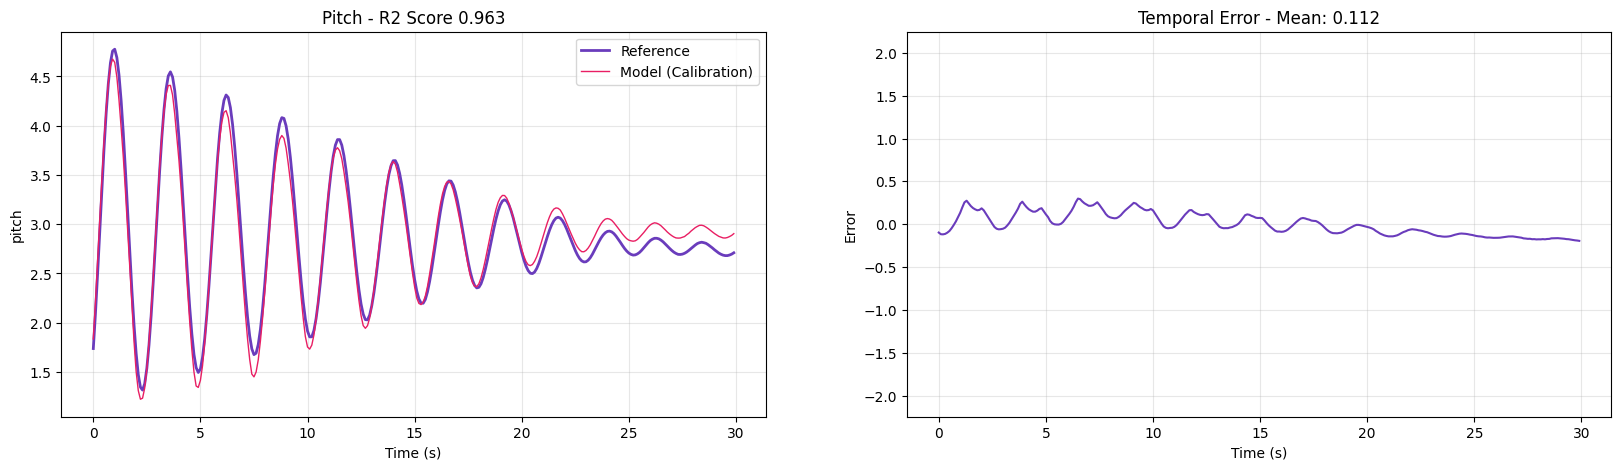

Dinamic Tests (pitch)


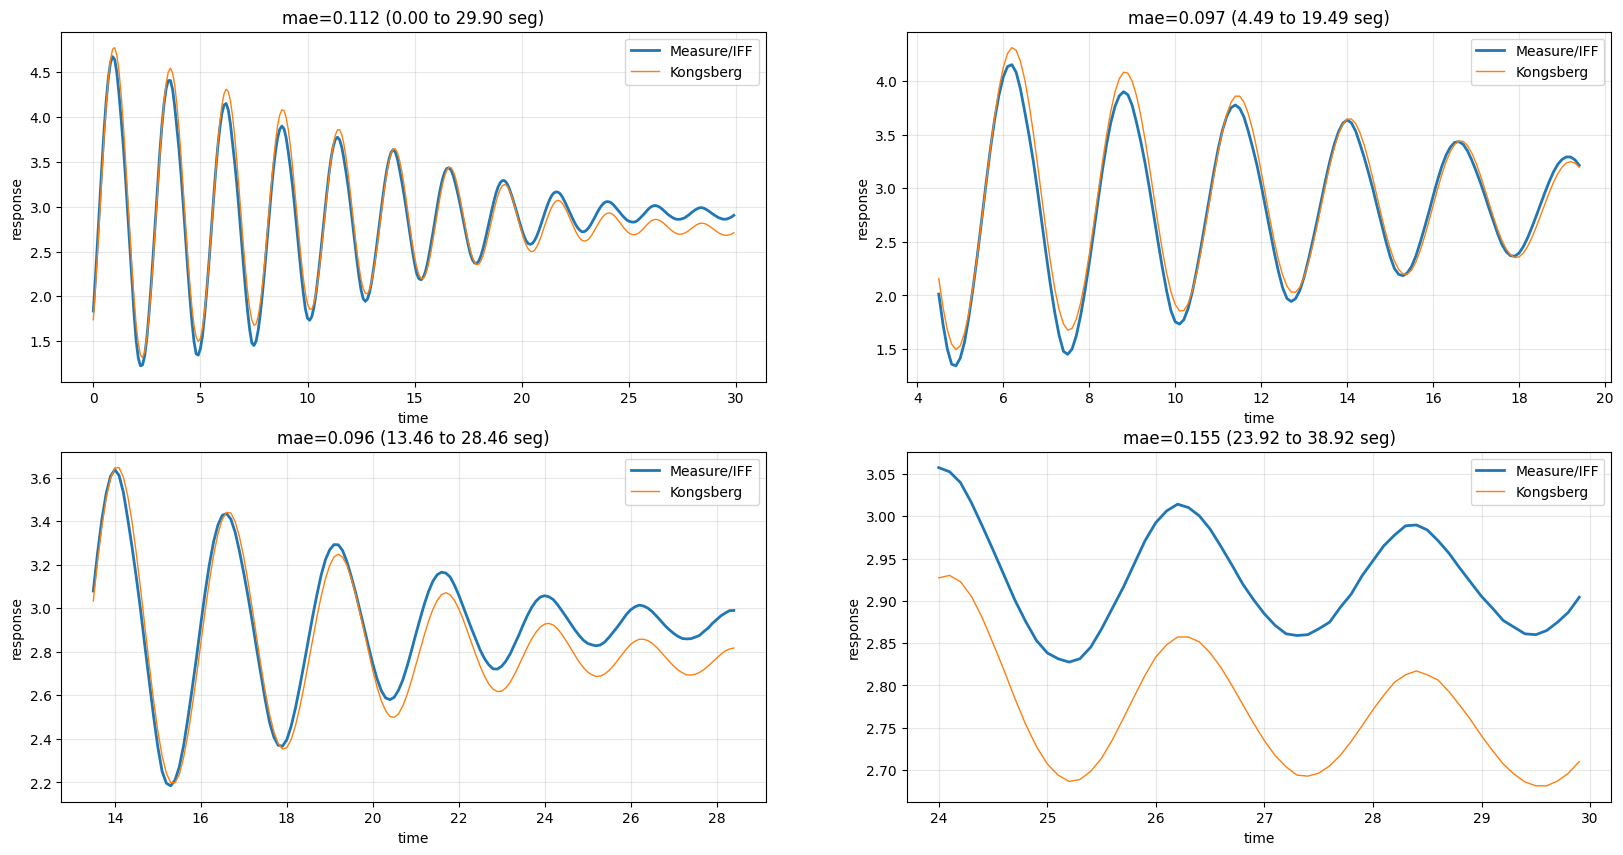

Static Tests (pitch)


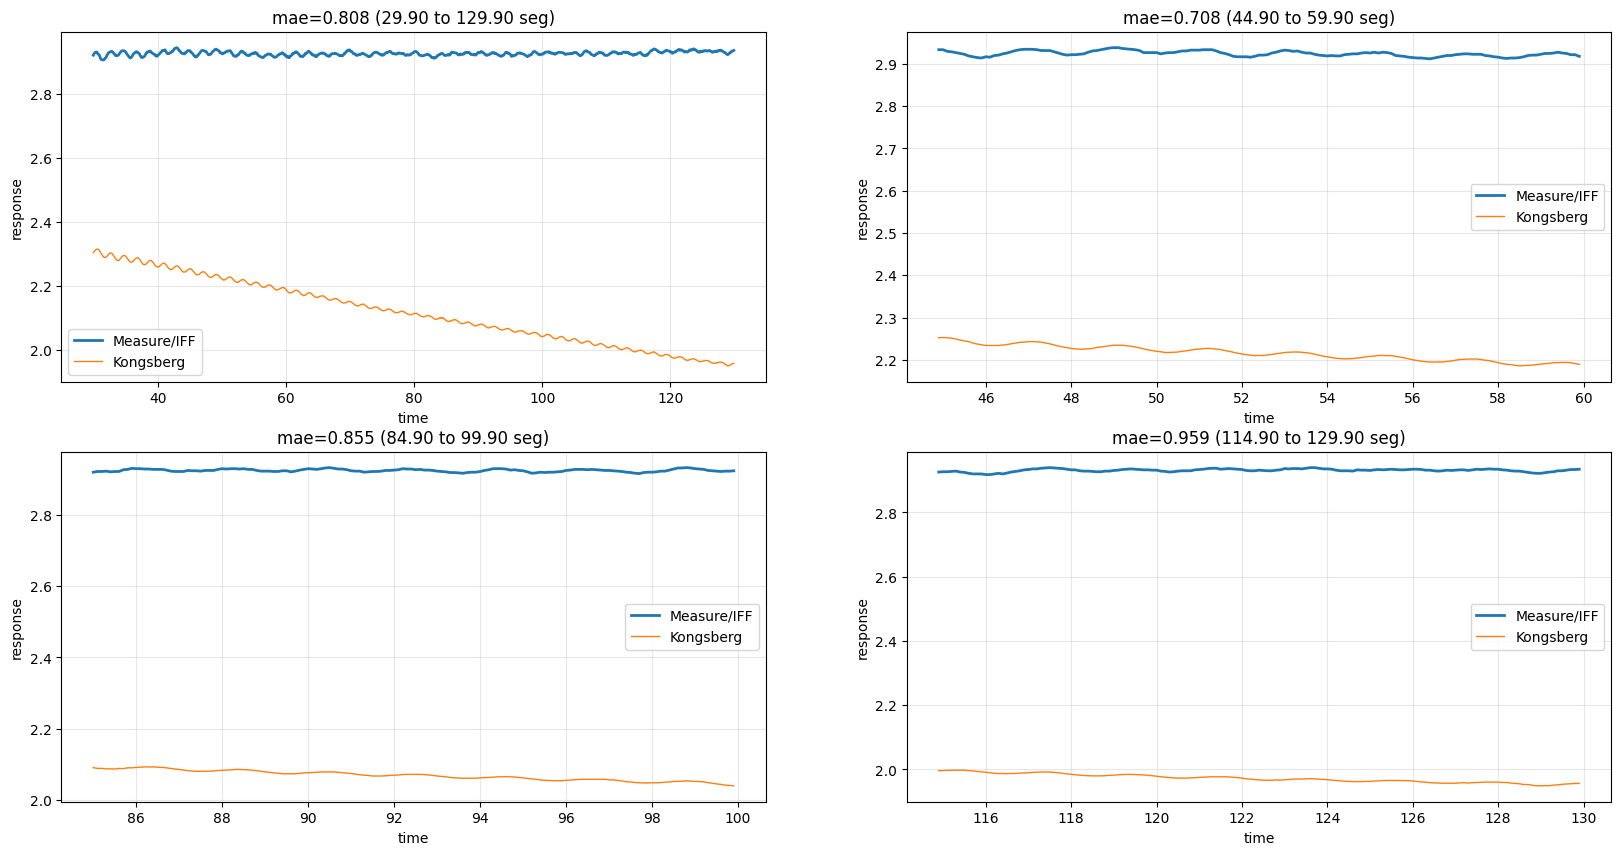

,wx,wy,wz,bias
wx_model,0.069135,0.000000,0.000000,-0.009546
wy_model,0.000000,-0.198900,0.000000,-0.160545
wz_model,0.000000,0.000000,-0.969850,-0.029918


------------------------------------------------------------------------------------- WZ -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,max_error_stat,max_error_dyn,mean_error_stat,mean_error_dyn,rms_stat,rms_dyn,std_stat,std_dyn,time_drift
0,0.9775,0.197792,0.247791,0.504562,1.109074,0.727086,1.109074,0.727086,0.254696,0.247791,0.252281,0.247791,0.404167


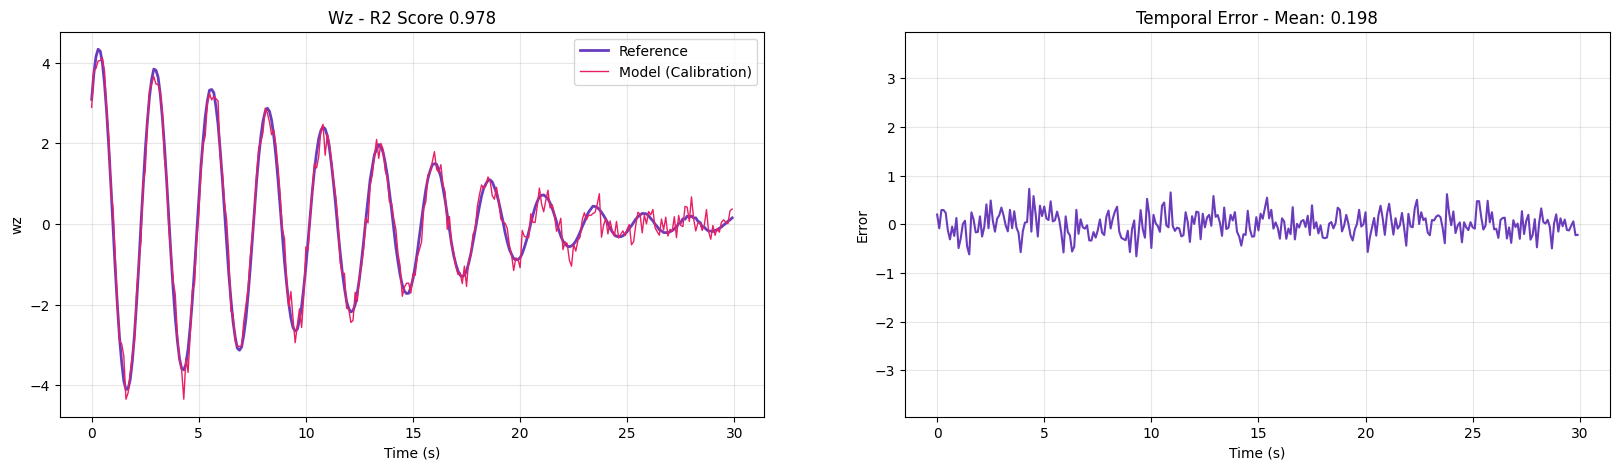

Dinamic Tests (wz)


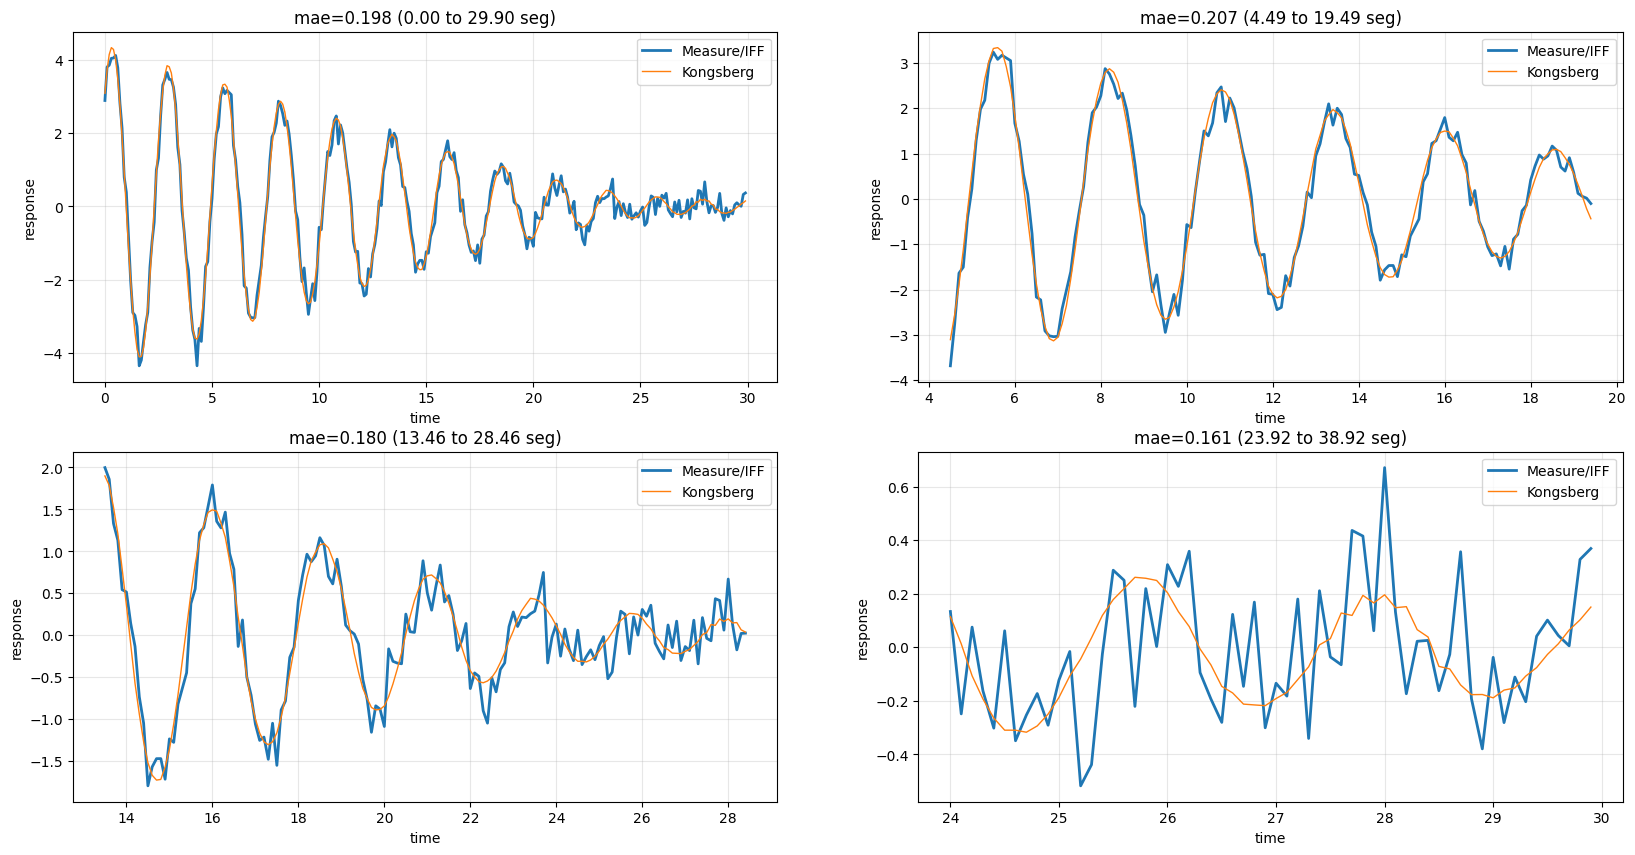

Static Tests (wz)


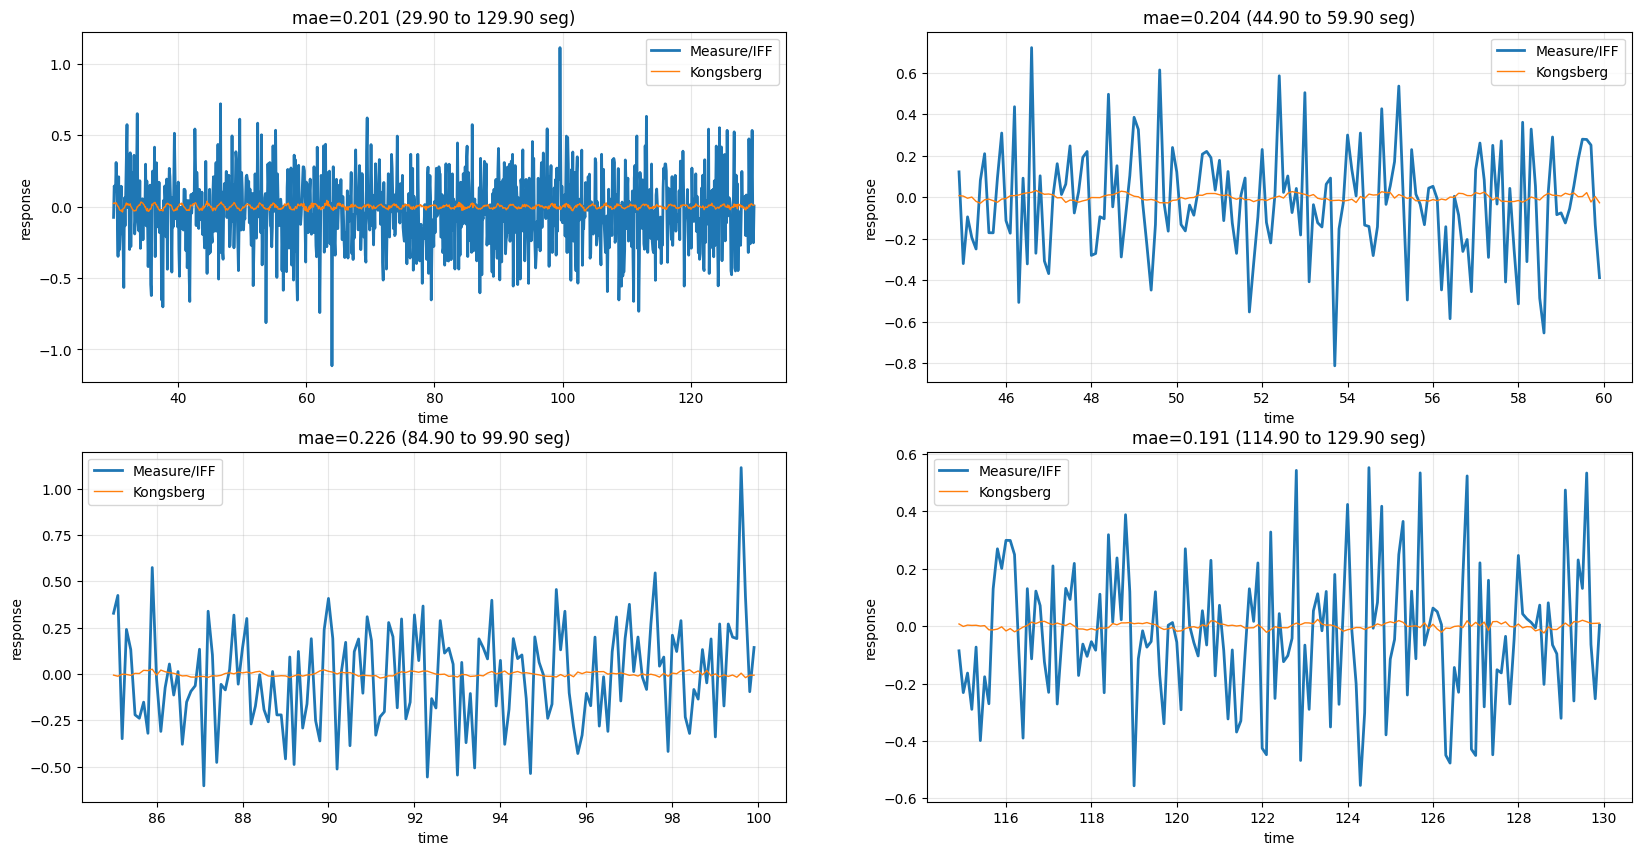

,ax,ay,az,bias
ax_model,0.408111,0.000000,0.000000,-0.095298
ay_model,0.000000,-0.057401,0.000000,10.345240
az_model,0.000000,0.000000,-0.025987,-0.188947


------------------------------------------------------------------------------------- AX -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,max_error_stat,max_error_dyn,mean_error_stat,mean_error_dyn,rms_stat,rms_dyn,std_stat,std_dyn,time_drift
0,0.392342,0.012397,0.015538,0.017712,0.03715,0.045043,0.03715,0.045043,0.008975,0.015538,0.008856,0.015538,0.013306


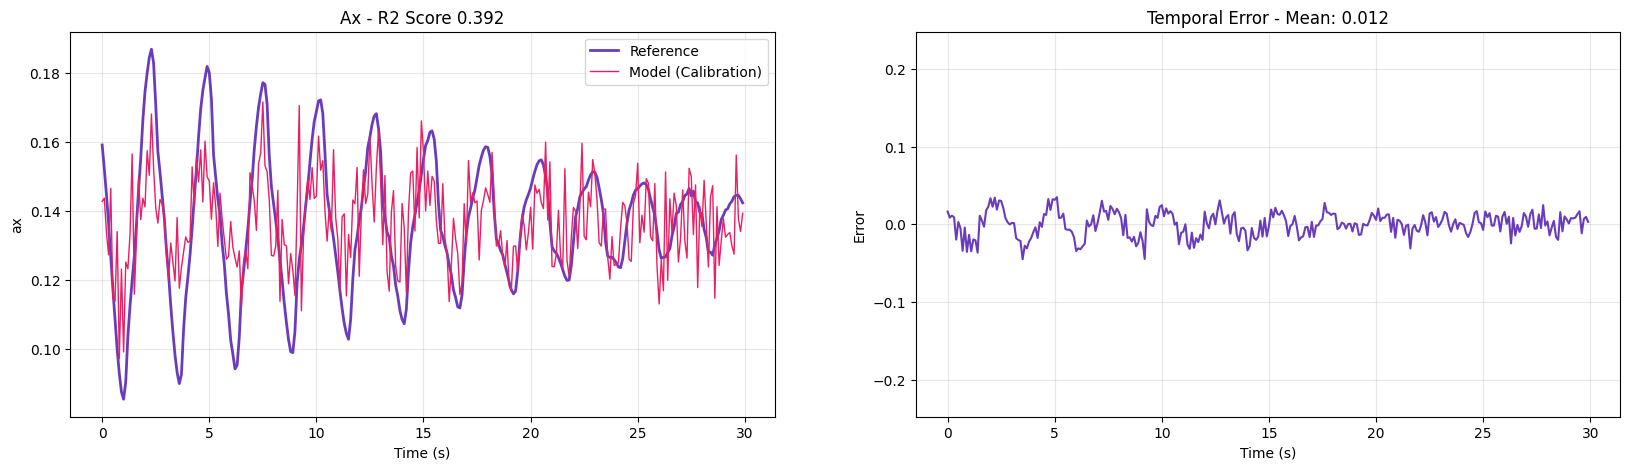

Dinamic Tests (ax)


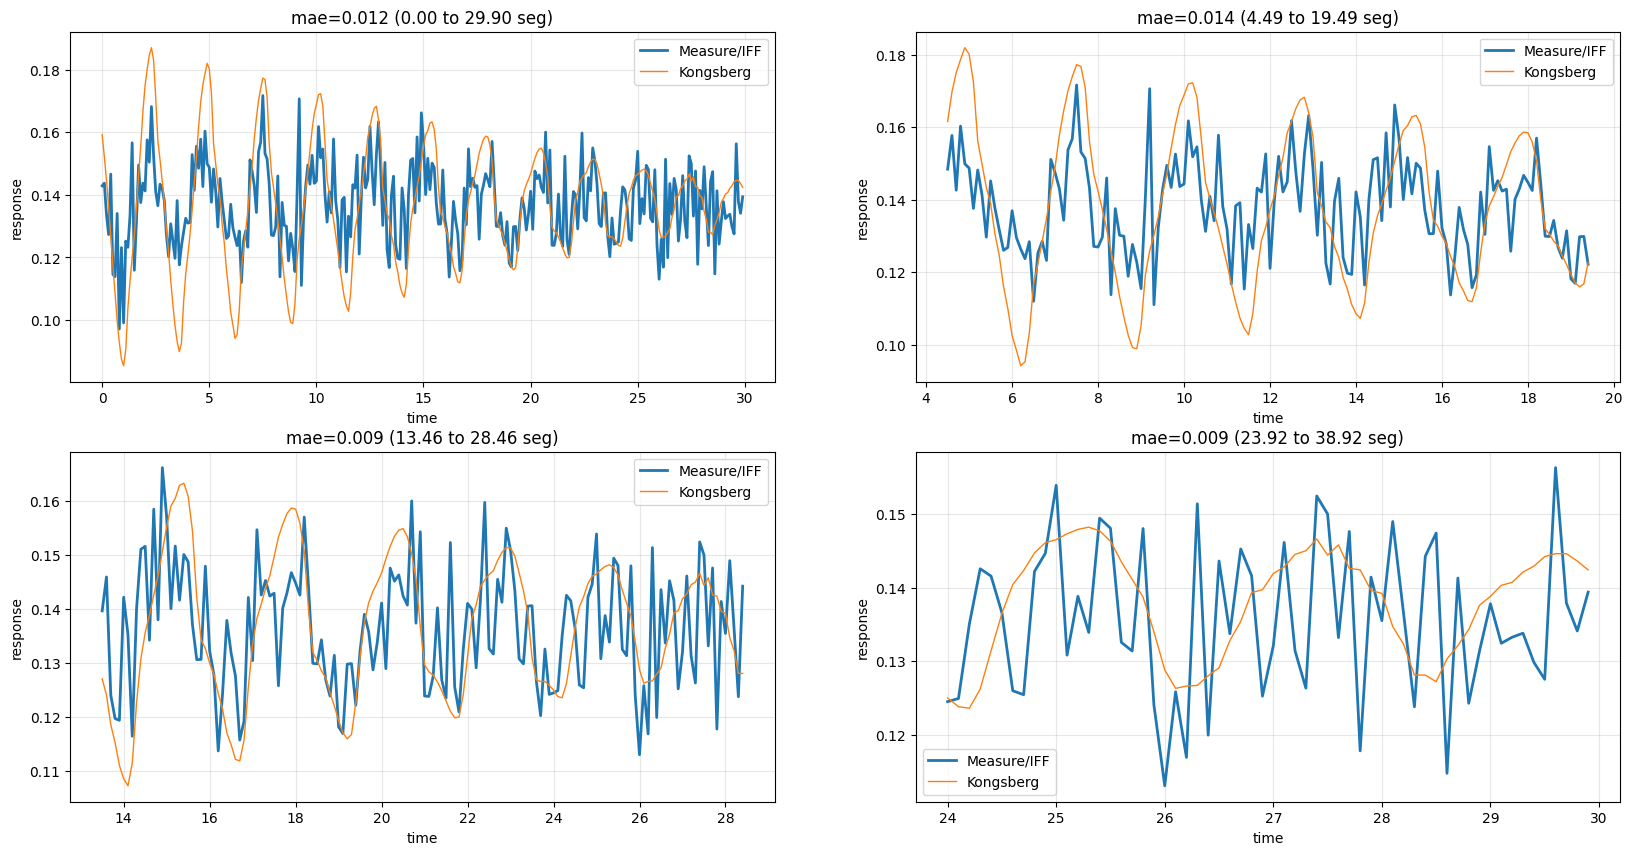

Static Tests (ax)


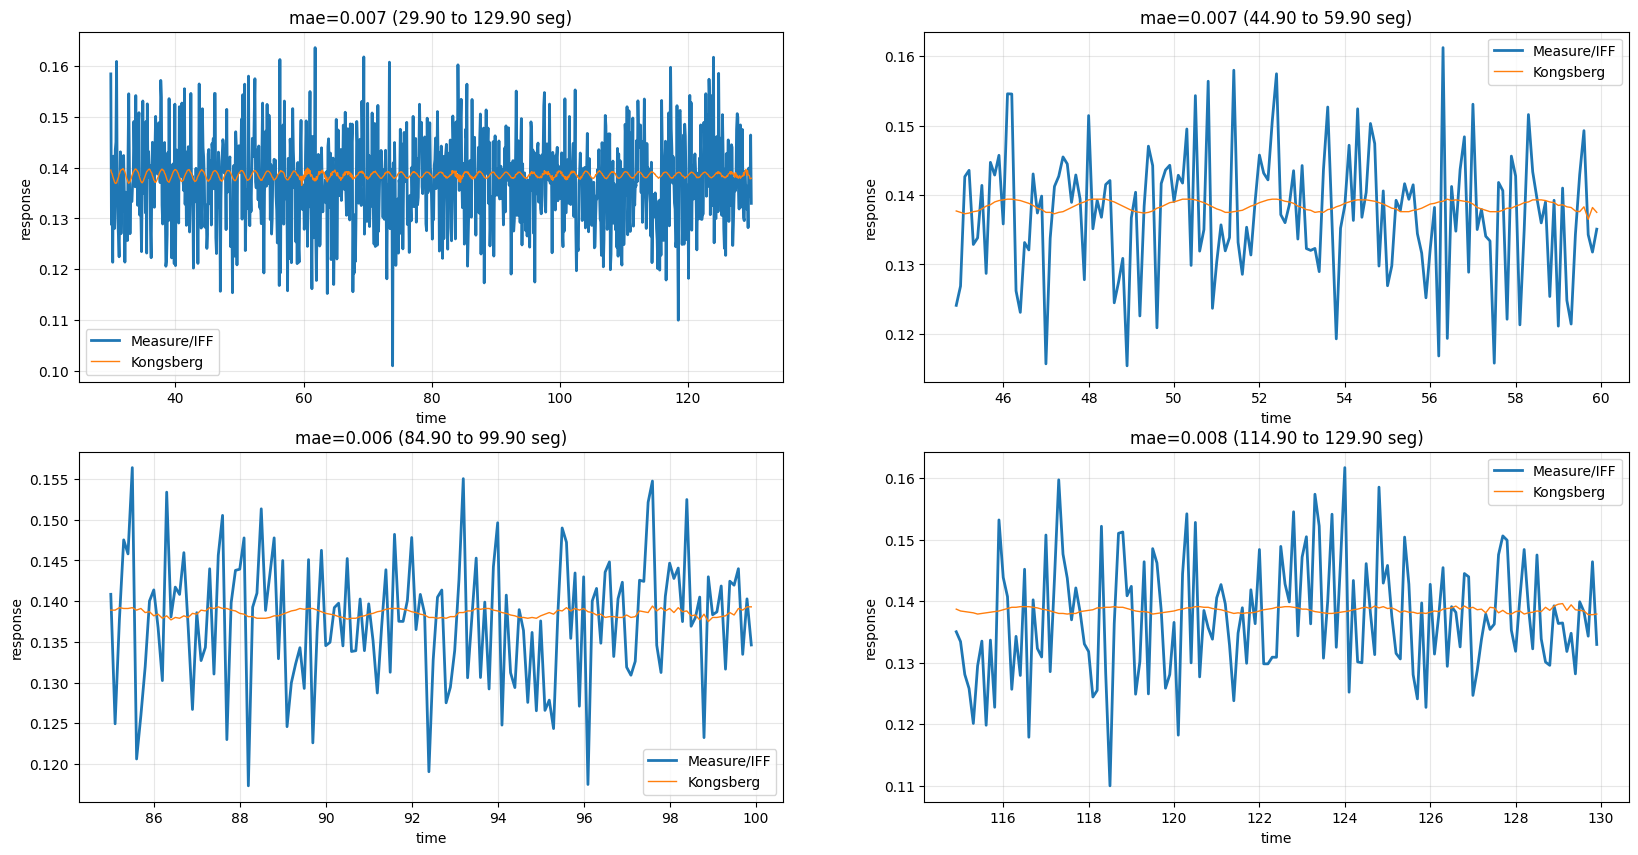

In [13]:
history = {}

for label, variables in groups.items():
    model = LinearFit(df_dynamic, variables, fuse=False)
    model.update()
    model.display()
    
    for idx, var in enumerate(variables):
        if var not in target_axis:
            continue

        df_dynamic['model_' + var] = model.predict(idx)
        df_static['model_'  + var] = df_static[[f'target_{v}' for v in variables]].values @ model.M[idx] + model.B[idx]
        
        print('-'*85, var.upper(), '-'*85)
        cal = CalibrationAnalysis(model, df_dynamic, df_static, var)
        cal.update()
        cal.display()
        model.metrics[var] = cal.metrics
        history[var]       = cal.metrics
                
        model.plot(idx)
        exporter = ResultExporter('Certificate', var, model)
        exporter.export()

        # ----------------------------- GRÁFICOS DE ZOOM ----------------------------- 
        print(f'Dinamic Tests ({var})')
        spacing = spacing_seconds/(df_dynamic.time.max() - df_dynamic.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0, 1))

        plt.subplot(2, 2, 2)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing))
        
        plt.subplot(2, 2, 3)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.45, 0.45+spacing))
        
        plt.subplot(2, 2, 4)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.8, 0.8+spacing))
        plt.show()

        print(f'Static Tests ({var})')
        spacing = spacing_seconds/(df_static.time.max() - df_static.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0, 1), norm=False)

        plt.subplot(2, 2, 2)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing), norm=False)

        plt.subplot(2, 2, 3)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.55, 0.55+spacing), norm=False)

        plt.subplot(2, 2, 4)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.85, 0.85+spacing), norm=False)
        plt.show()

In [14]:
pd.DataFrame(history).T.drop(columns=['correctionMatrixRow'])

,r2,mae,rmse,precision,max_error_stat,max_error_dyn,mean_error_stat,mean_error_dyn,rms_stat,rms_dyn,std_stat,std_dyn,time_drift
pitch,0.963083,0.11234,0.130223,0.208755,0.978233,0.299199,0.978233,0.299199,0.814504,0.130223,0.104377,0.130223,-12.984132
wz,0.9775,0.197792,0.247791,0.504562,1.109074,0.727086,1.109074,0.727086,0.254696,0.247791,0.252281,0.247791,0.404167
ax,0.392342,0.012397,0.015538,0.017712,0.03715,0.045043,0.03715,0.045043,0.008975,0.015538,0.008856,0.015538,0.013306
